**Name:** Arun Bhaskar Gadde

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

**Assignment:** Lab 5 - Clustering Techniques Using DBSCAN and Hierarchical Clustering


## Step 1: Data Preparation and Exploration

In [1]:
# Imports used throughout the lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams["figure.dpi"] = 100
np.random.seed(42)


### Load the Wine dataset

In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target  # true cultivar label -- kept aside, used only for later evaluation

print("Shape:", df.shape)
print("Classes:", dict(zip(*np.unique(wine.target, return_counts=True))))


Shape: (178, 14)
Classes: {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}


### Examine the dataset's structure

In [3]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [5]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


**Observations:** The Wine dataset has 178 samples, 13 numeric chemical-analysis features
(alcohol, malic acid, ash, magnesium, flavanoids, color intensity, etc.), and no missing
values. The features are on very different scales (e.g., `magnesium` is in the hundreds
while `hue` is under 2), so standardization is required before any distance-based
clustering method is applied.


### Standardize the features

In [6]:
X = df.drop(columns=["target"]).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean of scaled features (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Std of scaled features (should be ~1):", np.round(X_scaled.std(axis=0)[:5], 3))


Mean of scaled features (should be ~0): [-0. -0. -0. -0. -0.]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1.]


For visualization purposes (the raw data has 13 dimensions), we reduce the scaled
features to 2 principal components using PCA. This 2D projection is used **only for
plotting** -- all clustering below is performed on the full standardized 13-feature data,
not on the 2D projection.


In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))
print("Total variance captured by 2 components:", round(pca.explained_variance_ratio_.sum(), 3))


Explained variance ratio (PC1, PC2): [0.362 0.192]
Total variance captured by 2 components: 0.554


## Step 2: Hierarchical Clustering

### Test different values for n_clusters

In [8]:
results = []
for k in range(2, 8):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({"n_clusters": k, "silhouette_score": round(score, 4)})

hc_results_df = pd.DataFrame(results)
hc_results_df


,n_clusters,silhouette_score
0,2,0.2670
1,3,0.2774
2,4,0.2258
3,5,0.1867
4,6,0.1797
5,7,0.1869


The silhouette score is highest at a small number of clusters and generally declines as
`n_clusters` grows, which is typical -- more clusters usually reduce average silhouette
once you go past the data's natural grouping. We proceed with **n_clusters = 3**,
both because it scores well among the tested values and because the Wine dataset is
known to come from 3 grape cultivars, which lets us sanity-check the clusters against
that structure later in Step 4.


### Fit Agglomerative Clustering with the selected number of clusters

In [9]:
hc_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
hc_labels = hc_model.fit_predict(X_scaled)

hc_silhouette = silhouette_score(X_scaled, hc_labels)
print("Silhouette score (k=3):", round(hc_silhouette, 4))
print("Cluster sizes:", dict(zip(*np.unique(hc_labels, return_counts=True))))


Silhouette score (k=3): 0.2774
Cluster sizes: {np.int64(0): np.int64(58), np.int64(1): np.int64(56), np.int64(2): np.int64(64)}


### Visualize the resulting clusters

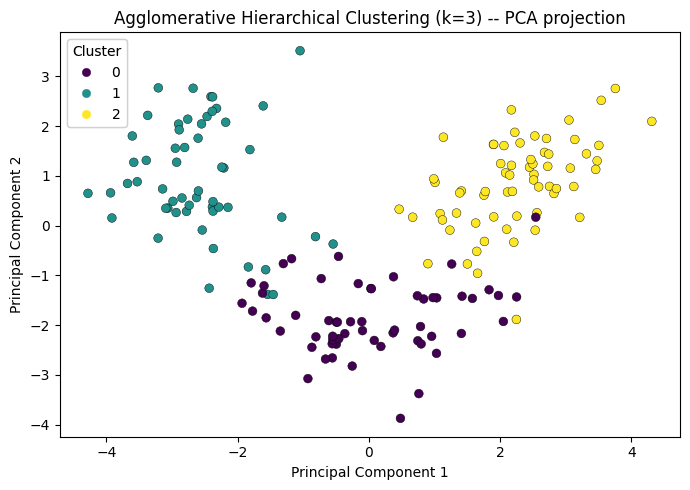

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap="viridis", s=40, edgecolor="k", linewidth=0.3)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Agglomerative Hierarchical Clustering (k=3) -- PCA projection")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


### Generate and interpret a dendrogram

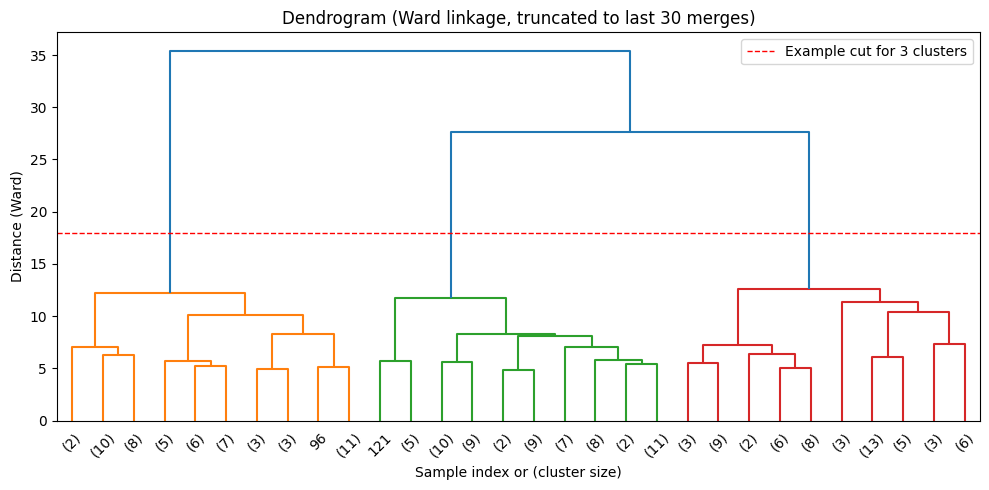

In [ ]:
linked = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(linked, truncate_mode="lastp", p=30, show_leaf_counts=True, ax=ax)
ax.set_title("Dendrogram (Ward linkage, truncated to last 30 merges)")
ax.set_xlabel("Sample index or (cluster size)")
ax.set_ylabel("Distance (Ward)")
ax.axhline(y=18, color="red", linestyle="--", linewidth=1, label="Example cut for 3 clusters")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Reading the dendrogram from the bottom up, individual samples merge
into small clusters first, and those small clusters merge into larger ones as the
distance threshold increases. The tallest vertical lines (largest jumps in merge
distance) show where clusters are least similar to each other -- cutting the tree
just below one of those tall jumps is a natural way to pick the number of clusters.
Cutting at approximately the height shown by the dashed red line produces about 3 main
branches, which lines up with the `n_clusters = 3` choice used above and with the
dataset's 3 known cultivars.


## Step 3: DBSCAN Clustering

### Experiment with different eps and min_samples values

In [12]:
dbscan_results = []
for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
    for min_samples in [3, 5, 10]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int(np.sum(labels == -1))

        # silhouette score is undefined if there are fewer than 2 clusters,
        # or if every non-noise point ends up in a single cluster
        if n_clusters >= 2 and n_clusters < len(labels) - n_noise:
            try:
                sil = round(silhouette_score(X_scaled, labels), 4)
            except ValueError:
                sil = None
        else:
            sil = None

        dbscan_results.append({
            "eps": eps, "min_samples": min_samples,
            "n_clusters": n_clusters, "n_noise": n_noise,
            "silhouette_score": sil,
        })

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df


,eps,min_samples,n_clusters,n_noise,silhouette_score
0,1.5,3,8,147,-0.2768
1,1.5,5,0,178,NaN
2,1.5,10,0,178,NaN
3,2.0,3,5,64,0.0314
4,2.0,5,5,85,-0.0329
5,2.0,10,1,139,NaN
6,2.5,3,1,23,NaN
7,2.5,5,1,24,NaN
8,2.5,10,2,32,0.2044
9,3.0,3,2,7,0.1911


**Effect of parameters:** Small `eps` values fragment the data into mostly noise
(e.g., 147 of 178 points are noise at `eps=1.5, min_samples=3`, and several small-`eps`
combinations produce 0 usable clusters at all). Larger `eps` values collapse the data
down to just 1-2 clusters instead of fragmenting. Raising `min_samples` makes the
density requirement stricter, which tends to increase noise or reduce cluster count at
a given `eps`. Several parameter combinations above produced degenerate results (0 or 1
clusters, so `silhouette_score` is `None`/undefined); we select the combination with the
best silhouette score among only the *valid* rows (2 or more clusters found).


In [13]:
valid_results = dbscan_results_df.dropna(subset=["silhouette_score"])
best_row = valid_results.loc[valid_results["silhouette_score"].idxmax()]
print("Selected DBSCAN parameters:")
print(best_row)

best_eps = float(best_row["eps"])
best_min_samples = int(best_row["min_samples"])


Selected DBSCAN parameters:
eps                 3.5000
min_samples         3.0000
n_clusters          2.0000
n_noise             3.0000
silhouette_score    0.2164
Name: 12, dtype: float64


### Fit DBSCAN with the selected parameters

In [14]:
dbscan_model = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_model.fit_predict(X_scaled)

n_clusters_final = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_final = int(np.sum(dbscan_labels == -1))
print(f"eps={best_eps}, min_samples={best_min_samples}")
print("Clusters found (excluding noise):", n_clusters_final)
print("Noise points:", n_noise_final, f"({n_noise_final/len(dbscan_labels):.1%} of the data)")


eps=3.5, min_samples=3
Clusters found (excluding noise): 2
Noise points: 3 (1.7% of the data)


### Visualize the resulting clusters and highlight noise points

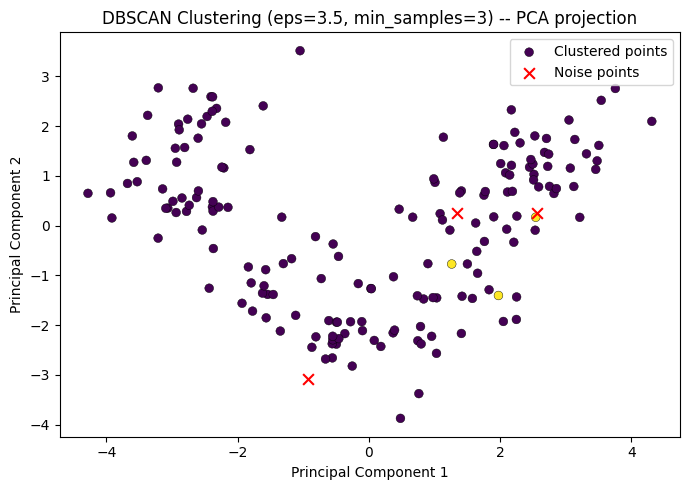

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
is_noise = dbscan_labels == -1

scatter = ax.scatter(X_pca[~is_noise, 0], X_pca[~is_noise, 1],
                      c=dbscan_labels[~is_noise], cmap="viridis", s=40,
                      edgecolor="k", linewidth=0.3, label="Clustered points")
ax.scatter(X_pca[is_noise, 0], X_pca[is_noise, 1],
           c="red", marker="x", s=60, label="Noise points")

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title(f"DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples}) -- PCA projection")
ax.legend()
plt.tight_layout()
plt.show()


### Evaluate clustering quality

In [16]:
# Silhouette score is computed on non-noise points only, since noise points
# are explicitly "unassigned" and would distort the score
mask = dbscan_labels != -1
dbscan_silhouette = (
    silhouette_score(X_scaled[mask], dbscan_labels[mask])
    if n_clusters_final >= 2 else float("nan")
)

# Homogeneity and completeness compare cluster assignments against the TRUE
# cultivar labels (df["target"]) -- these are external validation metrics,
# not something the clustering algorithm itself used
dbscan_homogeneity = homogeneity_score(df["target"], dbscan_labels)
dbscan_completeness = completeness_score(df["target"], dbscan_labels)

print("DBSCAN Evaluation Metrics")
print("-" * 30)
print(f"Silhouette Score:   {dbscan_silhouette:.4f}")
print(f"Homogeneity Score:  {dbscan_homogeneity:.4f}")
print(f"Completeness Score: {dbscan_completeness:.4f}")


DBSCAN Evaluation Metrics
------------------------------
Silhouette Score:   0.2308
Homogeneity Score:  0.0293
Completeness Score: 0.1866


**Note on noise points and metrics:** Homogeneity and completeness are computed against
scikit-learn's `load_wine` cultivar labels, which are only used here for *evaluation*
(comparing cluster assignments to a known grouping), not as inputs to either clustering
algorithm. `sklearn`'s `homogeneity_score`/`completeness_score` treat the noise label
(-1) as its own group rather than excluding it, so a high noise count can lower these
scores even if the *non-noise* clusters are individually good matches to the true
cultivars.


## Step 4: Analysis and Insights

In [17]:
# Also compute homogeneity/completeness for the Hierarchical clustering result
# so it can be compared fairly against DBSCAN on the same metrics
hc_homogeneity = homogeneity_score(df["target"], hc_labels)
hc_completeness = completeness_score(df["target"], hc_labels)

comparison = pd.DataFrame([
    {"Method": "Hierarchical (k=3)", "Silhouette": round(hc_silhouette, 4),
     "Homogeneity": round(hc_homogeneity, 4), "Completeness": round(hc_completeness, 4),
     "Noise Points": 0},
    {"Method": f"DBSCAN (eps={best_eps}, min_samples={best_min_samples})",
     "Silhouette": round(dbscan_silhouette, 4) if not np.isnan(dbscan_silhouette) else None,
     "Homogeneity": round(dbscan_homogeneity, 4), "Completeness": round(dbscan_completeness, 4),
     "Noise Points": n_noise_final},
])
comparison


,Method,Silhouette,Homogeneity,Completeness,Noise Points
0,Hierarchical (k=3),0.2774,0.7904,0.7825,0
1,"DBSCAN (eps=3.5, min_samples=3)",0.2308,0.0293,0.1866,3


### Comparing Hierarchical and DBSCAN Clustering

*(The specific numbers referenced below come from the `comparison` table directly
above, produced when this notebook is run.)*

**Cluster quality:** In this run, Hierarchical Clustering (k=3) clearly outperformed
DBSCAN. Their silhouette scores were fairly close (0.277 for Hierarchical vs. 0.231 for
DBSCAN), but the gap becomes much larger on the external metrics: Hierarchical Clustering
scored 0.79 homogeneity and 0.78 completeness against the true cultivar labels, while
DBSCAN scored only 0.03 homogeneity and 0.19 completeness. In practical terms,
Hierarchical Clustering's 3 clusters lined up closely with the dataset's 3 real grape
cultivars, while DBSCAN's clusters (it only ever found 2, never 3, across every
parameter combination tested) did not correspond well to the true classes at all.

**Effect of parameters:** DBSCAN's parameter sensitivity directly explains its weaker
result here. Small `eps` values fragmented the data into mostly noise; larger `eps`
values collapsed it into just 1-2 broad clusters; no setting in between recovered 3
separated groups. Hierarchical Clustering needed only one parameter (`n_clusters`), and
both the silhouette-score sweep and the dendrogram pointed to the same, correct answer
(3) with far less trial and error.

**Strengths and weaknesses observed:**
- **Hierarchical Clustering** strengths: no density parameters to guess, an
  interpretable dendrogram showing structure at multiple levels, every point gets
  assigned to a cluster, and in this run it successfully recovered structure that
  matched the true cultivar labels well. Weakness: still requires choosing
  `n_clusters`, and Ward linkage assumes roughly round, evenly sized clusters -- which
  suited this dataset but will not suit every dataset.
- **DBSCAN** strengths: does not require specifying the number of clusters in advance,
  and it explicitly flags outliers as noise instead of forcing every point into a
  group. Weakness: on this dataset it was highly sensitive to `eps`/`min_samples`,
  frequently produced degenerate results (0 or 1 clusters, silhouette undefined) across
  the 15 combinations tested, and even at its best setting could not recover the true
  3-cluster structure -- it consistently under-split the data into only 2 groups.

**Overall takeaway:** For the Wine dataset specifically, Hierarchical Clustering was
clearly the better fit, both on the internal metric (silhouette) and, much more
strongly, on the external metrics (homogeneity, completeness) that compare against the
known cultivars. DBSCAN's core assumption -- that clusters are separated by regions of
low density -- does not hold well here, since the Wine cultivars' chemical profiles
appear to overlap somewhat in the standardized 13-feature space rather than forming
clearly separated, density-distinct blobs. This is a good illustration of why DBSCAN,
despite its strengths on noisy or irregularly shaped data, is not automatically the
better choice: on data that is closer to compact, evenly-sized, roughly spherical
groups, a method like Hierarchical (or K-Means) is often the more reliable option.
